In [1]:
'''
Names: Prashant Ram, Muhammad Hassan, Gandhar Tare, Mohamed Burhan
Course: CSC 177
Assignment: 3 - Linear Regression
Professor: Jagannadha Chidella
Details: 
'''

import pandas
import seaborn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn import tree
import graphviz
import matplotlib.pyplot as plt
from IPython.display import HTML, display



In [2]:
display( HTML("<h1><strong>Doing a little preprocessing justtt to be sure</strong></h1>"))

'''
This block reads the data from a .csv file and makes columns for the data
'''
try:
    # import the data from the .csv file. "data" = dataframe. Our data is using ; as a separator and quotes to enclose
    # the data. The first row is the header row so we use the correct separator and quote character or else pandas treats these
    # data as a single column which we don't want.
    data = pandas.read_csv('Churn_Modelling.csv')

    #print the data attribute columns
    print(data.columns)
        
    # print the number of rows and columns
    print(f'We have {data.shape[0]} rows')
    print(f'We have {data.shape[1]} columns')

    # print the first 5 rows of the data
    print('\n', data.head())
        
except Exception as e:
    print("An error occured while trying to read from the CSV file", e)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
We have 10000 rows
We have 14 columns

    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00      

In [3]:
'''
This block counts the number of missing values in each column
'''

#list to hold the columns with missing values
missingColumns = []

#our original number of rows with unclean data
original_rows = data.shape[0]

try:
    #loop through the columns and get the number of missing values
    for i in data.columns:
        #get the total of column of missing values
        total = data[i].isnull().sum()
        #display the column and the missing values number
        print(f"{i}: {total}")

        #add missing value columns to the list
        if total > 0:
            missingColumns.append(i)

    #finally display which columns had missing values
    if len(missingColumns) == 0:
        print("\nThere were no missing values in the data set.")
    else:
        #display the columns with missing values
        print(f"\nThese columns had missing data: {missingColumns}")
    
#catch any reading errors
except Exception as e:
    print("umm. An error occurred while trying to count the missing values..", e)

RowNumber: 0
CustomerId: 0
Surname: 0
CreditScore: 0
Geography: 0
Gender: 0
Age: 0
Tenure: 0
Balance: 0
NumOfProducts: 0
HasCrCard: 0
IsActiveMember: 0
EstimatedSalary: 0
Exited: 0

There were no missing values in the data set.


In [4]:
'''
This block drops all rows and columns with missing data
'''
# print the number of rows and columns
original_rows = data.shape[0]
original_columns = data.shape[1]
print(f'We have {original_rows} [original] rows and {original_columns} columns')
print('\nOriginal Data:', data.head())
    
#drops all rows with no data
data = data.dropna()

clean_rows = data.shape[0]
clean_columns = data.shape[1]
print(f'\nWe have {clean_rows} [Clean] rows and {clean_columns} columns')
print('\nCleaned data Data:', data.head())

print(f'\n\nWe had {original_rows - clean_rows} rows and {original_columns - clean_columns} columns of missing data')

We have 10000 [original] rows and 14 columns

Original Data:    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        1

In [5]:
'''This block checks for duplicate rows and drops the ones that are duplicates'''
total_duplicates = data.duplicated().sum()

if total_duplicates != 0:
    data = data.drop_duplicates(inkeep='first')
    print(f"\nThere were {total_duplicates} duplicate rows in the data set.")
else:
    print("\nThere were no duplicate rows in the data set.")



There were no duplicate rows in the data set.


In [6]:
display(HTML("<h1><strong>Start of Assignment 3</strong></h1>"))

In [7]:
display( HTML("<h1><strong>Part 2 : Classification Model On Given Dataset</strong></h1>"))

In [8]:
'''This block drops all columns which do not help the model learn'''
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(data.columns)


Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


In [9]:
'''This block converts all the categorical data to numerical data using one-hot encoding.'''

data['Geography'] = data['Geography'].replace({'France': 2, 'Spain': 1, 'Germany':0}).infer_objects(copy=False)
data['Gender'] = data['Gender'].replace({'Female': 1, 'Male': 0}).infer_objects(copy=False)

C:\Users\rampr\AppData\Local\Temp\ipykernel_102960\1481568574.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Geography'] = data['Geography'].replace({'France': 2, 'Spain': 1, 'Germany':0}).infer_objects(copy=False)
C:\Users\rampr\AppData\Local\Temp\ipykernel_102960\1481568574.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Gender'] = data['Gender'].replace({'Female': 1, 'Male': 0}).infer_objects(copy=False)


In [10]:
'''We want to look at the relationship between Gender, Age, Balance, IsActiveMember, Salary with respect to Exited'''
# seaborn.pairplot(data[['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',  'Balance', 'NumOfProducts', 'HasCrCard','IsActiveMember', 'EstimatedSalary', 'Exited']], hue='Exited', diag_kind='kde')

'We want to look at the relationship between Gender, Age, Balance, IsActiveMember, Salary with respect to Exited'

In [11]:
'''Lets get our Predictor and Target features'''
x = data.drop(['Exited'], axis=1)
y = data['Exited']

first_k_rows = data.iloc[:1000]
test_y = first_k_rows['Exited']
test_x = first_k_rows.drop(['Exited'], axis=1)

In [12]:
'''
1. We attempt to create the Naive Baynes model
'''

from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB as naive_bayes

classification_naive_bayes = naive_bayes()
classification_naive_bayes.fit(x, y)
y_pred_naive_bayes = classification_naive_bayes.predict(test_x)
print(f'Naive Bayes Accuracy achieved is: {accuracy_score(test_y, y_pred_naive_bayes)}')

Naive Bayes Accuracy achieved is: 0.787


---Trying odd values of k from 1 to 21---
KNN Accuracy achieved with k=1 is: 1.0
KNN Accuracy achieved with k=3 is: 0.8404
KNN Accuracy achieved with k=5 is: 0.8163
KNN Accuracy achieved with k=7 is: 0.8072
KNN Accuracy achieved with k=9 is: 0.8033
KNN Accuracy achieved with k=11 is: 0.8016
KNN Accuracy achieved with k=13 is: 0.7989
KNN Accuracy achieved with k=15 is: 0.7969
KNN Accuracy achieved with k=17 is: 0.7974
KNN Accuracy achieved with k=19 is: 0.7973
KNN Accuracy achieved with k=21 is: 0.7972


---Trying even values of k from 2 to 2---
KNN Accuracy achieved with k=2 is: 0.8398
KNN Accuracy achieved with k=4 is: 0.8152
KNN Accuracy achieved with k=6 is: 0.8062
KNN Accuracy achieved with k=8 is: 0.804
KNN Accuracy achieved with k=10 is: 0.8001
KNN Accuracy achieved with k=12 is: 0.799
KNN Accuracy achieved with k=14 is: 0.7977
KNN Accuracy achieved with k=16 is: 0.7972
KNN Accuracy achieved with k=18 is: 0.7971
KNN Accuracy achieved with k=20 is: 0.7969
KNN Accuracy achieved wit

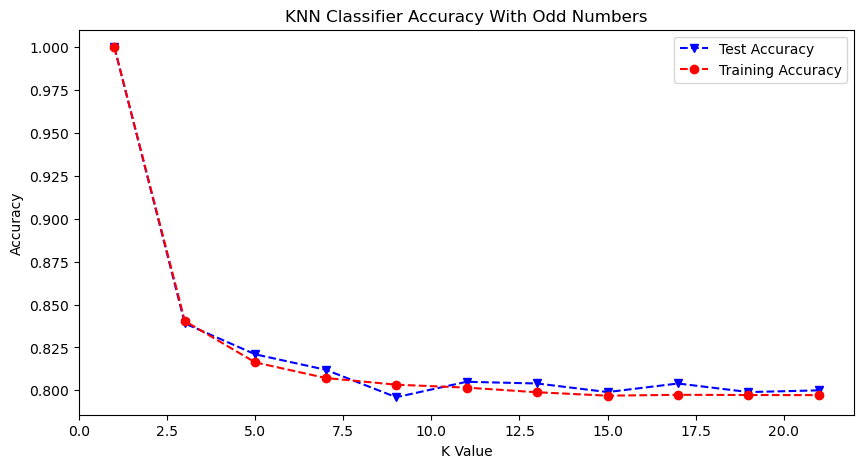

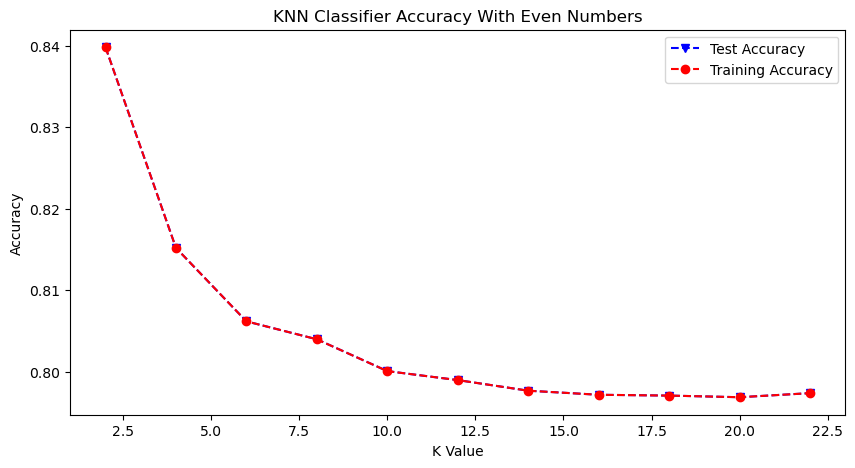

In [13]:
'''
2. We attempt to create the KNN model
'''
from sklearn.neighbors import KNeighborsClassifier as neighbor

odd_neighbors = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
even_neighbors = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]
test_accuracy = []
training_accuracy = []

# we try to use odd values of k from 1 to 21
print('---Trying odd values of k from 1 to 21---')
for i in range(1, 22, 2):
    classification_knn = neighbor(n_neighbors=i)
    classification_knn.fit(x, y)
    y_pred_knn = classification_knn.predict(test_x)
    y_pred_knn_train = classification_knn.predict(x)
    test_accuracy.append(accuracy_score(test_y, y_pred_knn))
    training_accuracy.append(accuracy_score(y, y_pred_knn_train))
    print(f'KNN Accuracy achieved with k={i} is: {accuracy_score(y, y_pred_knn_train)}') 
print('\n')

# we try to use even values of k from 2 to 22
print('---Trying even values of k from 2 to 2---')
for i in range(2, 23, 2):
    classification_knn = neighbor(n_neighbors=i)
    classification_knn.fit(x, y)
    y_pred_knn = classification_knn.predict(x)
    test_accuracy.append(accuracy_score(y, y_pred_knn))
    training_accuracy.append(accuracy_score(y, y_pred_knn))
    print(f'KNN Accuracy achieved with k={i} is: {accuracy_score(y, y_pred_knn)}')


# Separate accuracies for odd and even neighbors
odd_test_accuracy = test_accuracy[:len(odd_neighbors)]
odd_training_accuracy = training_accuracy[:len(odd_neighbors)]
even_test_accuracy = test_accuracy[len(even_neighbors):]
even_training_accuracy = training_accuracy[len(even_neighbors):]

# Plotting for odd neighbors
plt.figure(figsize=(10, 5))
plt.plot(odd_neighbors, odd_test_accuracy, 'bv--', odd_neighbors, odd_training_accuracy, 'ro--')
plt.title('KNN Classifier Accuracy With Odd Numbers')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.legend(['Test Accuracy', 'Training Accuracy'])
plt.show()

# Plotting for even neighbors
plt.figure(figsize=(10, 5))
plt.plot(even_neighbors, even_test_accuracy, 'bv--', even_neighbors, even_training_accuracy, 'ro--')
plt.title('KNN Classifier Accuracy With Even Numbers')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.legend(['Test Accuracy', 'Training Accuracy'])
plt.show()



In [14]:
# '''
# 3. We attempt to create the Support Vector Machine (SVM) model
# '''
# from sklearn.svm import SVC as svc

# c_parameter = [0.1] #add more it is too slow for more ones but do add
# svl_test_accuracy = []
# svl_training_accuracy = []

# for i in c_parameter:
#     classification_svm = svc(kernel='linear', C=i, random_state=0)
#     classification_svm.fit(x, y)
#     y_pred_svm = classification_svm.predict(test_x)
#     y_pred_svm_train = classification_svm.predict(x)
#     svl_test_accuracy.append(accuracy_score(y, y_pred_svm))
#     svl_training_accuracy.append(accuracy_score(y, y_pred_svm_train))
#     print(f'SVM Accuracy achieved with C={i} is: {accuracy_score(y, y_pred_svm)}')

# plt.plot(c_parameter, svl_test_accuracy,'ro--', c_parameter, svl_training_accuracy,'bv--')
# plt.legend(['Test Accuracy','Train Accuracy'])
# plt.xlabel('C')
# plt.xscale('log')
# plt.ylabel('Accuracy')

# print(f'SVM Accuracy achieved is: {accuracy_score(test_y, y_pred_svm)}')


Decision Tree Accuracy achieved is: 0.843


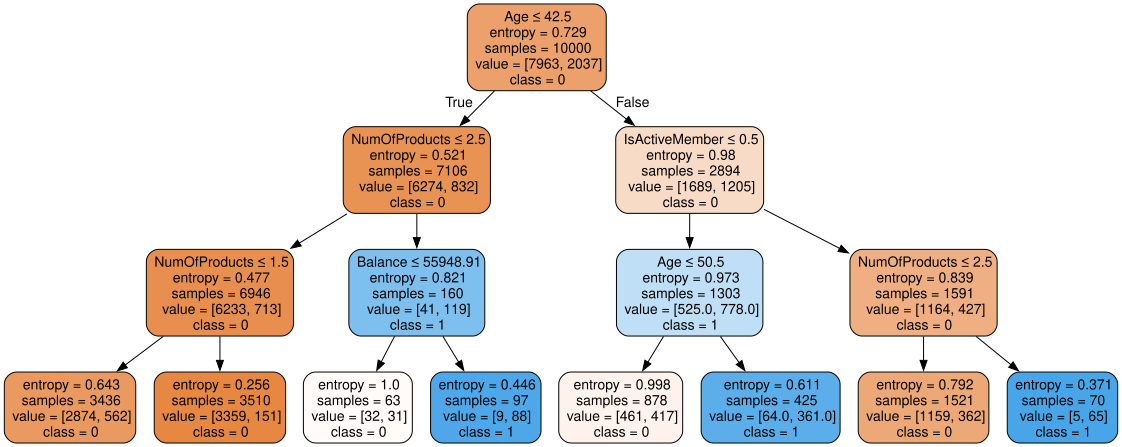

In [ ]:
'''
4. We attempt to create the Decision Tree model
'''
decisionTree = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)
decisionTree = decisionTree.fit(x, y)
y_pred_tree = decisionTree.predict(test_x)

tree_data = tree.export_graphviz(decisionTree, out_file=None,
                                feature_names=x.columns,
                                class_names=['0', '1'],
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(tree_data)

print(f'Decision Tree Accuracy achieved is: {accuracy_score(test_y, y_pred_tree)}')

# draw the graph
graph

c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Logistic Regression Accuracy achieved with C=0.01 is: 0.7933
Logistic Regression Accuracy achieved with C=0.1 is: 0.7926
Logistic Regression Accuracy achieved with C=0.2 is: 0.7926
Logistic Regression Accuracy achieved with C=0.5 is: 0.7927


c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Logistic Regression Accuracy achieved with C=0.8 is: 0.7929
Logistic Regression Accuracy achieved with C=1 is: 0.7927
Logistic Regression Accuracy achieved with C=2 is: 0.7928
Logistic Regression Accuracy achieved with C=5 is: 0.7926
Logistic Regression Accuracy achieved with C=10 is: 0.7927
Logistic Regression Accuracy achieved with C=20 is: 0.7927

Decision Tree Accuracy achieved is: 0.843


c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\rampr\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Text(0, 0.5, 'Accuracy')

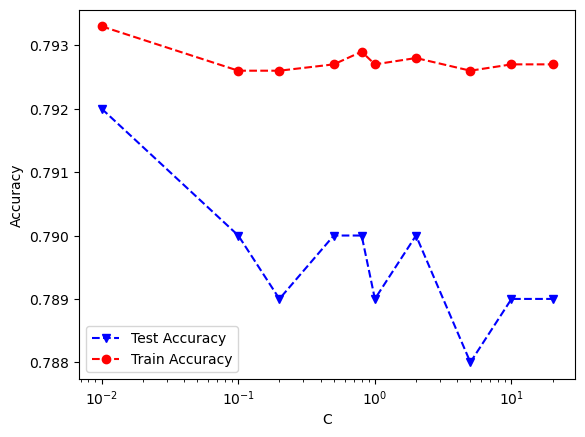

In [ ]:
'''
4. We attempt to create the Logistic Regression model
'''
from sklearn.linear_model import LogisticRegression as logistic

c_parama_logistic = [0.01, 0.1, 0.2, 0.5, 0.8, 1, 2, 5, 10, 20]

logistic_test_accuracy = []
logistic_training_accuracy = []

for i in c_parama_logistic:
    classification_logistic = logistic(C=i, random_state=0)
    classification_logistic.fit(x, y)
    y_pred_logistic = classification_logistic.predict(test_x)
    y_pred_logistic_train = classification_logistic.predict(x)
    logistic_test_accuracy.append(accuracy_score(test_y, y_pred_logistic))
    logistic_training_accuracy.append(accuracy_score(y, y_pred_logistic_train))
    print(f'Logistic Regression Accuracy achieved with C={i} is: {accuracy_score(y, y_pred_logistic_train)}')

plt.plot(c_parama_logistic, logistic_test_accuracy,'bv--', c_parama_logistic, logistic_training_accuracy,'ro--')
plt.legend(['Test Accuracy','Train Accuracy'])
plt.xlabel('C')
plt.xscale('log')
plt.ylabel('Accuracy')

In [ ]:
print(f'\nDecision Tree Accuracy achieved is: {accuracy_score(test_y, y_pred_tree)}')

In [ ]:
display(HTML("<h1><strong>Part 3: Feature Selection And Data Splitting</strong></h1>"))

# Part 3:
# A good train and test split is always useful. Duplicates in training and test set should be avoided. Any ML model that trains on a training set which helps explain a lot of variance in the data tend to yield higher accuracy on test set.
# The task of this part is simple: Find a train-test split ratio (for example 80:20) that you think will be best for your ML model to be trained and tested on.


In [ ]:
'''Since we will be dealing with Decision Tree Classifier, k-Nearest Neighbor, we will create a pipeline object to ensure reusuability of the code since 
preprocessing and training for each model will be an expensive task'''

# we have to select our numerica and categorical features. We can get it through running dtypes() and take note of the "object" class.
data_types  = data.dtypes
print(data_types)

CreditScore          int64
Geography            int64
Gender               int64
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [ ]:
'''                           FEATURE SELECTION
We found that #Geography and #Gender are categorical features. Rest are Numerical
'''

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer as Si
from sklearn.preprocessing import StandardScaler as Stdscaler, OneHotEncoder as OHE
from sklearn.compose import ColumnTransformer

# we have to select our numerica and categorical features. We can get it through running dtypes() and take note of the "object" class.
numeric_features   = ["CreditScore", "Age", "Tenure", "Balance", 
                      "NumOfProducts", "EstimatedSalary"]

categorical_features  = ["Geography", "Gender"]

# build the two pipelines
numeric_pipe = Pipeline([('impute', Si(strategy="median")),('scale', Stdscaler())])
categorical_pipe = Pipeline([('impute', Si(strategy="constant", fill_value='missing')),('one-hot', OHE(handle_unknown='ignore'))])

# combine the two pipelines into a single column transformer
combined_pipeline = ColumnTransformer([('numeric', numeric_pipe, numeric_features),('categorical', categorical_pipe, categorical_features)])


In [ ]:
'''We create a model for the requirements'''

from sklearn.linear_model import LogisticRegression as logistic
from sklearn.tree import DecisionTreeClassifier as decision_tree
from sklearn.neighbors import KNeighborsClassifier as neighbor
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB as naive_bayes

models = {
    'Logistic Regression': Pipeline([('combined_pipeline', combined_pipeline), ('Logistic', logistic())]),
    'Decision Tree': Pipeline([('combined_pipeline', combined_pipeline), ('Decision Tree', decision_tree())]),
    'K-Nearest Neighbor': Pipeline([('combined_pipeline', combined_pipeline), ('K-Nearest Neighbor', neighbor())]),
    'Support Vector Classifier': Pipeline([('combined_pipeline', combined_pipeline), ('SVC', SVC())]),
    'Naive Bayes': Pipeline([('combined_pipeline', combined_pipeline), ('Naive Bayes', naive_bayes())])
}

In [ ]:
'''                         DATA SPLITTING
We are going to find the best train split mechanism by trying different split ratios.
'''
test_ratio = [0.5, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
results = []

for items, pipe in models.items():
    for ratio in test_ratio:
        # split the data into training and testing sets
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ratio, random_state=42, stratify=y, shuffle=True)
        # fit the pipeline to the training data
        pipe.fit(x_train, y_train)
        split_score = pipe.score(x_test, y_test)
        # append the split score to results
        results.append((items, ratio, split_score))
        print(f"Model: {items}, Test Ratio: {ratio}, Score: {split_score}")
    print('\n')


ValueError: fill_value='missing' (of type <class 'str'>) cannot be cast to the input data that is dtype('int64'). Make sure that both dtypes are of the same kind.

In [ ]:
'''Get the best model and split ratio from above'''
another_data = pandas.DataFrame(results, columns=['Model', 'Test Ratio', 'Score'])
best_split_ratio = another_data.loc[another_data.groupby('Model')['Score'].idxmax()]
print("Best Model and their Split Ratio Results:\n", best_split_ratio)

Best Model and their Split Ratio Results:
                         Model  Test Ratio     Score
12              Decision Tree        0.15  0.784667
21         K-Nearest Neighbor        0.10  0.845000
5         Logistic Regression        0.30  0.800333
40                Naive Bayes        0.50  0.807000
34  Support Vector Classifier        0.25  0.857200


In [ ]:
'''Through the test we found out the a ratio of 0.25 worked the best for the split so we will utilize that.'''
from sklearn.metrics import accuracy_score

preprocessed_data = ColumnTransformer(transformers=[('numeric', Stdscaler(), numeric_features),('Categorical', OHE(), categorical_features)])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y, shuffle=True)
pipeline = Pipeline([('preprocess', preprocessed_data), ('classifier', logistic())])
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
accuracy_of_prediction = accuracy_score(y_test, y_pred)
print(f'Accuracy of prediction is: {accuracy_of_prediction}')


Accuracy of prediction is: 0.7976


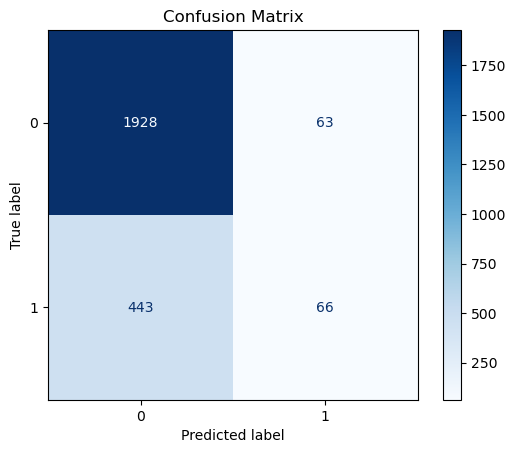

Accuracy on test data is 0.80
F1 score on test data is 0.88
Precision Score on test data is 0.81
Recall score on test data is 0.97
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1991
           1       0.51      0.13      0.21       509

    accuracy                           0.80      2500
   macro avg       0.66      0.55      0.55      2500
weighted avg       0.75      0.80      0.75      2500

Exited column unique values are: [1 0]


In [ ]:
'''Generate a Confusion Matrix to see how well the model is performing'''
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

#generate a confusion matrix
confusion = confusion_matrix(y_test, y_pred)

# plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# we can use either 0 or 1 for "position" the results would be the same.
print(f'Accuracy on test data is %.2f' % accuracy_of_prediction)
print(f'F1 score on test data is %.2f' % f1_score(y_test, y_pred, pos_label=0))
print(f'Precision Score on test data is %.2f' % precision_score(y_test, y_pred, pos_label=0))
print(f'Recall score on test data is %.2f' % recall_score(y_test, y_pred, pos_label=0))
print(classification_report(y_test, y_pred))

# print the unique values in the Exited column just for our sanity check
print('Exited column unique values are:', data.Exited.unique())



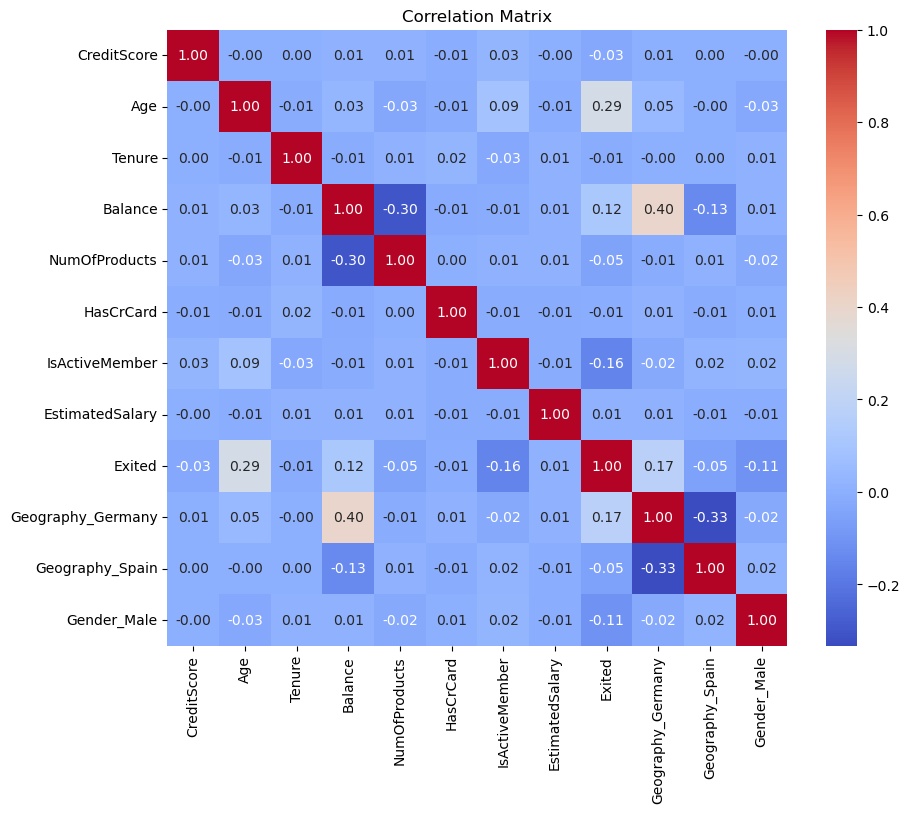

In [ ]:
'''We are going to plot a coorelation map of features to see how much are they correlated with each other'''

coorelation = pandas.get_dummies(data, drop_first=True).corr()
plt.figure(figsize=(10, 8))
seaborn.heatmap(coorelation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()